In [1]:
import os
import sys

# Add the project root to the path
PROJECT_ROOT = '/Users/lekiaprosper/Documents/CoMoChEng/Prometheus/kineticmodelssite'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Load environment variables from .env.dev
from dotenv import load_dotenv
load_dotenv(os.path.join(PROJECT_ROOT, '.env.dev'))

# Configure Django settings
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'kms.settings')

# Allow Django ORM in async context (Jupyter notebooks)
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = 'true'

import django
django.setup()

# Fix duplicate output caused by colorama (initialized by Django)
try:
    import colorama
    colorama.deinit()
except:
    pass

In [25]:
from database.models.kinetic_model import KineticModel, KineticsComment, ThermoComment
from database.models.reaction_species import Structure
from database.models.kinetic_data import Kinetics
from database.models.thermo_transport import Thermo, Thermo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
kinetic_models = KineticModel.objects.all()
for model in kinetic_models:
    print(f'Model: {model.model_name}, Species count: {model.species.count()}, Reactions count: {model.kinetics.count()}')


Model: Reduced-DRG-GRI-mech, Species count: 19, Reactions count: 15
Model: PCI2013/325-Husson, Species count: 233, Reactions count: 1401
Model: PCI2013/335-Wang, Species count: 1379, Reactions count: 5636
Model: PCI2013/353-Malewicki, Species count: 345, Reactions count: 2159
Model: PCI2013/269-Matsugi, Species count: 141, Reactions count: 563
Model: PCI2013/289-Dagaut, Species count: 322, Reactions count: 7116
Model: PCI2013/361-Malewicki, Species count: 2013, Reactions count: 7778
Model: PCI2013/411-Darcy, Species count: 942, Reactions count: 4062
Model: PCI2013/599-Veloo, Species count: 113, Reactions count: 0
Model: GRI-17-species-mech, Species count: 17, Reactions count: 56
Model: Chernov, Species count: 64, Reactions count: 0
Model: 2-BTP, Species count: 204, Reactions count: 1495
Model: PCI2015/0153-Marshall, Species count: 20, Reactions count: 66
Model: Narayanaswamy, Species count: 173, Reactions count: 1008
Model: H2-3, Species count: 16, Reactions count: 52
Model: MB-Dooley,

In [4]:
harris_model = kinetic_models.get(model_name='Harris-Butane')
harris_model.model_name

'Harris-Butane'

In [5]:
harris_species_dict = {}
for species in harris_model.species.all():
    for structure_ids in species.isomers.values_list("structure", flat=True):
        structures = Structure.objects.filter(id=structure_ids)
        harris_species_dict[structures.first().isomer.formula.formula] = structures.first().smiles
        # print(structures.first().smiles)


print(harris_species_dict)

{'C4H10': 'CCCC', 'C2H4': 'C=C', 'C3H6': 'C=CC', 'CH3': '[CH3]', 'C2H3O': 'C=C[O]', 'C2H3': '[CH]=C', 'C2H5': 'C[CH2]', 'C2H4O': 'C=CO', 'CH3O2': 'CO[O]', 'C2H5O2': 'CCO[O]', 'C2H6O2': 'CCOO', 'C4H9': 'C[CH]CC', 'C4H9O2': 'C[CH]CCOO', 'C4H10O2': 'CCCCOO', 'C4H8': 'CC=CC', 'C4H7': 'C=C[CH]C', 'C4H9O': 'CCCC[O]', 'C3H8O2': 'CCCOO', 'O2': '[O][O]', 'HO2': '[O]O', 'C2H2O': 'C=C=O', 'H2O2': 'OO', 'H': '[H]', 'H2': '[H][H]', 'CH4': 'C', 'HO': '[OH]', 'H2O': 'O', 'O': '[O]', 'C3H5': '[CH2]C=C', 'C4H10O4': 'OOCCCCOO', 'C4H9O4': '[O]OCCCCOO', 'CH4O2': 'COO', 'C4H8O3': 'O=CCCCOO', 'C4H9O3': '[O]CCCCOO', 'C3H7O2': 'CCCO[O]', 'C4H7O2': '[O]CCCC=O', 'C4H6O2': 'O=CCCC=O', 'C3H4': 'C=C=C'}


In [6]:
# Get all models with the same species in the harris model
for formula, smiles in harris_species_dict.items():
    matching_models = KineticModel.objects.filter(species__isomers__formula__formula=formula).distinct()
    print(f"Models matching {formula}: {matching_models}")
    for model in matching_models:
        print(f" - {model.model_name}")
    print("\n")


Models matching C4H10: <QuerySet [<KineticModel: 222 PCI2019/639-Cai>, <KineticModel: 12 AramcoMech_1.3>, <KineticModel: 217 PCI2017/111-Jin>, <KineticModel: 212 PCI2017/052-Li>, <KineticModel: 27 AramcoMech_2.0>, <KineticModel: 201 PCI2013/599-Veloo>, <KineticModel: 22 2-BTP>, <KineticModel: 31 USC_Mech_ii>, <KineticModel: 108 CombFlame2013/1939-Cai>, <KineticModel: 25 MB-Dooley>, <KineticModel: 44 EL24115>, <KineticModel: 43 Biomass>, <KineticModel: 179 CombFlame2013/2291-Somers>, <KineticModel: 149 PCI2017/024-Bohon>, <KineticModel: 102 CombFlame2013/17-Malewicki>, <KineticModel: 199 PCI2013/361-Malewicki>, <KineticModel: 197 PCI2013/335-Wang>, <KineticModel: 145 PCI2015/0325-Nawdiyal>, <KineticModel: 195 PCI2013/297-Herbinet>, <KineticModel: 196 PCI2013/325-Husson>, '...(remaining elements truncated)...']>
 - PCI2019/639-Cai
 - AramcoMech_1.3
 - PCI2017/111-Jin
 - PCI2017/052-Li
 - AramcoMech_2.0
 - PCI2013/599-Veloo
 - 2-BTP
 - USC_Mech_ii
 - CombFlame2013/1939-Cai
 - MB-Dooley
 -

In [7]:
# Find all models with matching species thermochemistry

# First, find species that match your formulas
species_thermo_model_dict = {}
for formula, smiles in harris_species_dict.items():
    # Find thermo entries for species matching this formula
    matching_thermo = Thermo.objects.filter(
        species__isomers__formula__formula=formula
    ).distinct()
    
    # Find all KineticModels that use this thermochemistry
    models_with_thermo = KineticModel.objects.filter(
        thermo__in=matching_thermo
    ).distinct()
    
    if models_with_thermo.exists():
        species_thermo_model_dict[formula] = [model.model_name for model in models_with_thermo]


In [8]:
species_thermo_model_dict

{'C4H10': ['n-Heptane',
  'AramcoMech_1.3',
  '2-BTP',
  'MB-Dooley',
  'AramcoMech_2.0',
  'Gasoline_2',
  'USC_Mech_ii',
  'Gasoline_Surrogate',
  'Biomass',
  'EL24115',
  'Harris-Butane',
  'CombFlame2013/17-Malewicki',
  'CombFlame2013/1939-Cai',
  'CombFlame2013/2680-Vranckx',
  'CombFlame2013/487-Schenk',
  'CombFlame2017/176-Needham',
  'PCI2013/289-Dagaut',
  'PCI2013/401-Liu',
  'PCI2013/527-Sheen',
  'PCI2015/0325-Nawdiyal',
  'PCI2017/024-Bohon',
  'PCI2017/037-Sakai',
  'CombFlame2012/2028-Sarathy',
  'CombFlame2013/1541-Zhang',
  'CombFlame2013/1609-Veloo',
  'CombFlame2013/2291-Somers',
  'CombFlame2013/2712-Sarathy',
  'CombFlame2014/65-Darcy',
  'CombFlame2014/657-Jin',
  'CombFlame2014/798-Cai',
  'CombFlame2017/111-Atef',
  'CombFlame2019/1-Hanfeng',
  'PCI2013/225-Somers',
  'PCI2013/297-Herbinet',
  'PCI2013/325-Husson',
  'PCI2013/335-Wang',
  'PCI2013/353-Malewicki',
  'PCI2013/361-Malewicki',
  'PCI2013/411-Darcy',
  'PCI2013/599-Veloo',
  'PCI2015/0409-Zhang',


In [9]:
# Create an enthalpy table with rows for each species and columns for each model's enthalpy at a given temperature

TEMP = 300  # K

def safe_enthalpy(thermo, temp=TEMP):
    """Return enthalpy in kJ/mol (converted from J/mol)."""
    try:
        return round(thermo.enthalpy(temp) / 1000, 4)  # J/mol → kJ/mol
    except (ValueError, Exception):
        return None

# Collect all models that share species with Harris, put Harris first
other_model_names = sorted(set(
    model_name
    for models in species_thermo_model_dict.values()
    for model_name in models
    if model_name != 'Harris-Butane'
))
all_model_names = ['Harris-Butane'] + other_model_names

# Build table: rows = species (formula), columns = model enthalpy at TEMP K
enthalpy_table = {}

for formula in harris_species_dict.keys():
    enthalpy_table[formula] = {}
    
    for model_name in all_model_names:
        model = KineticModel.objects.get(model_name=model_name)
        
        # Find thermo for this species in this model
        thermo_entries = model.thermo.filter(
            species__isomers__formula__formula=formula
        ).distinct()
        
        if thermo_entries.exists():
            # Use first matching thermo entry
            h = safe_enthalpy(thermo_entries.first())
            enthalpy_table[formula][model_name] = h
        else:
            enthalpy_table[formula][model_name] = None

# Create DataFrame: rows=species, columns=models (Harris-Butane first)
df_enthalpy_matrix = pd.DataFrame.from_dict(enthalpy_table, orient='index')
df_enthalpy_matrix = df_enthalpy_matrix[all_model_names]  # enforce column order
df_enthalpy_matrix.index.name = 'Species (Formula)'

# Remove species where Harris-Butane has no thermo data
df_enthalpy_matrix = df_enthalpy_matrix.dropna(subset=['Harris-Butane'])

# Add a column showing how many models have data for each species
df_enthalpy_matrix['Models with data'] = df_enthalpy_matrix.notna().sum(axis=1)

# Sort: species with most model coverage first
df_enthalpy_matrix = df_enthalpy_matrix.sort_values('Models with data', ascending=False)

print(f"Enthalpy (kJ/mol) at {TEMP} K")
print(f"Species: {len(df_enthalpy_matrix)} | Models: {len(all_model_names)}")
df_enthalpy_matrix

Enthalpy (kJ/mol) at 300 K
Species: 18 | Models: 99


,Harris-Butane,2-BTP,AramcoMech_1.3,AramcoMech_2.0,Biomass,C1_C3_hydrofluorocarbons_NIST,CH2F2,Chernov,CombFlame2012/2028-Sarathy,CombFlame2013/1315-Chang,...,PCI2019/751-Chang,PCI2019/789-Lapointe1,PCI2019/789-Lapointe2,Reduced-DRG-GRI-mech,Shamel-Propane,USC_Mech_ii,butanol/1907-Merchant,butanol/2028-Sarathy,n-Heptane,Models with data
Species (Formula),,,,,,,,,,,,,,,,,,,,,
CH3,145.2689,146.9705,146.7710,146.7710,145.7717,146.9705,146.9705,146.7710,146.7710,146.7710,...,145.7737,146.7710,146.7710,146.9705,147.3619,146.9705,146.7623,146.7710,145.7737,95
C2H4,52.8881,52.5793,52.5793,52.6358,52.5438,52.5793,NaN,52.5793,52.5793,52.5438,...,52.5521,52.5793,52.5793,52.5793,52.3407,52.5793,52.5793,52.5793,52.5521,90
C2H5,119.3693,118.7511,121.1070,121.1070,117.3150,118.7511,NaN,118.7511,121.1070,117.3150,...,121.1070,118.7511,118.7511,NaN,121.2972,118.7511,119.7931,121.1070,121.1070,89
C2H3,296.7931,299.8175,296.6570,297.1315,286.3291,299.8175,NaN,296.6570,296.6570,286.3291,...,299.8511,299.8175,299.8175,NaN,297.3592,299.8175,NaN,296.6570,299.8511,81
C3H6,20.9505,20.5743,20.1194,26.2565,20.5743,20.5743,NaN,20.5324,20.1194,19.5769,...,20.4975,19.8206,19.8206,NaN,19.4260,20.5743,NaN,20.1194,20.4975,79
C2H3O,14.2251,13.0693,-10.2059,-10.2059,14.8054,25.2041,25.2041,-9.9058,-10.2059,NaN,...,-14.0476,18.8388,18.8388,NaN,-9.4106,13.0693,NaN,-10.2059,132.0152,79
C2H4O,-165.4496,-166.0869,-166.0869,-166.0869,-165.2191,-166.0869,NaN,-166.0869,-166.0869,NaN,...,-170.5391,-170.5959,-170.5959,NaN,-165.7150,-166.0869,NaN,-166.0869,-55.8583,78
C4H8,2.3636,-10.8242,0.1277,0.1173,-0.3858,NaN,NaN,-0.3858,0.1277,NaN,...,0.4521,-0.3013,NaN,NaN,NaN,-10.8242,NaN,0.1277,0.4521,68
CH3O2,9.5668,NaN,-176.3147,-176.3147,18.1007,NaN,NaN,NaN,-176.3147,NaN,...,9.3080,9.0990,9.0990,NaN,13.7675,NaN,NaN,-176.3147,9.3080,67


In [10]:
# ============================================================================
# STATISTICAL ANALYSIS: Each model vs Harris-Butane (pairwise on shared species)
# ============================================================================
# Metrics: Mean Bias, MAE, RMSE, Wilcoxon test (W, p, effect size r), Lin's CCC, Coverage
# All enthalpy values are in kJ/mol
# ============================================================================

from scipy import stats
from scipy.stats import norm

def lins_ccc(y_true, y_pred):
    """Lin's Concordance Correlation Coefficient — measures agreement, not just correlation.

    Uses the canonical form: CCC = (2 * r * sd_true * sd_pred) / (var_true + var_pred + (mean_diff)^2)
    where r is Pearson's correlation and all statistics use population (ddof=0) convention,
    consistent with Lin (1989) and https://rowannicholls.github.io/python/statistics/agreement/concordance_correlation_coefficient.html
    https://en.wikipedia.org/wiki/Concordance_correlation_coefficient

    Example: If two independent observers have measured the thermo properties of CH4, the CCC stats is measures the degree of agreement/reliability in the measurement.
    It evaluates the degree of reproducibility.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    # Pearson correlation coefficient
    cor = np.corrcoef(y_true, y_pred)[0][1]
    # Means
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    # Population variances and standard deviations (ddof=0)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    sd_true = np.std(y_true)
    sd_pred = np.std(y_pred)
    # CCC
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
    ccc = numerator / denominator
    return ccc

def wilcoxon_effect_size_r(w_stat, w_pval, n):
    """
    Compute Rosenthal's r = Z / sqrt(n) for the Wilcoxon signed-rank test.
    
    Z is recovered from the two-sided p-value: Z = ppf(1 - p/2).
    The sign of Z is inferred from W relative to its expected value E(W) = n(n+1)/4:
      - W < E(W) → more weight in positive ranks → positive Z (model > Harris)
      - W > E(W) → more weight in negative ranks → negative Z (model < Harris)
    
    |r| interpretation (Cohen/Rosenthal): ~0.1 small, ~0.3 medium, ~0.5 large
    https://peterstatistics.com/Terms/Correlations/RosenthalCorrelationCoefficient.html
    """
    if w_pval is None or n < 6:
        return None
    if w_pval >= 1.0:
        return 0.0
    # Recover |Z| from two-sided p-value
    z_abs = norm.ppf(1 - w_pval / 2)
    # Determine sign: W = min(W+, W-); E(W) = n(n+1)/4
    expected_w = n * (n + 1) / 4
    # If W < E(W), the test statistic (smaller rank sum) is unusually small,
    # meaning the other rank sum dominates. scipy returns W = min(W+, W-).
    # We use the convention: negative r means model tends to be less than Harris.
    z = z_abs if w_stat < expected_w else -z_abs
    r = z / np.sqrt(n)
    return r

harris_col = 'Harris-Butane'
harris_values = df_enthalpy_matrix[harris_col]
n_harris_species = harris_values.notna().sum()

stat_results = []

for model_name in other_model_names:
    model_values = df_enthalpy_matrix[model_name]
    
    # Only compare where BOTH Harris and this model have data
    mask = harris_values.notna() & model_values.notna()
    n_shared = mask.sum()
    
    if n_shared < 2:
        stat_results.append({
            'Model': model_name,
            'Shared Species': n_shared,
            'Coverage (%)': round(100 * n_shared / n_harris_species, 1),
            'Mean Bias (kJ/mol)': None, 'MAE (kJ/mol)': None, 'RMSE (kJ/mol)': None,
            'Pearson r': None, "Lin's CCC": None,
            'W stat': None, 'Wilcoxon p-value': None,
            'Effect Size r': None, 'Effect': None, 'Sig (p<0.05)': None,
        })
        continue
    
    h_vals = harris_values[mask].values.astype(float)
    m_vals = model_values[mask].values.astype(float)
    diffs = m_vals - h_vals
    
    # Error statistics (already in kJ/mol since enthalpy matrix is kJ/mol)
    mean_bias = np.mean(diffs)
    mae = np.mean(np.abs(diffs))
    rmse = np.sqrt(np.mean(diffs ** 2))
    
    # Correlation
    if np.std(h_vals) > 0 and np.std(m_vals) > 0:
        pearson_r, _ = stats.pearsonr(h_vals, m_vals)
        ccc = lins_ccc(h_vals, m_vals)
    else:
        pearson_r = None
        ccc = None
    
    # Wilcoxon signed-rank test (non-parametric, tests if median diff ≠ 0)
    # Needs at least 6 non-zero differences to be meaningful
    non_zero_diffs = diffs[diffs != 0]
    w_stat = None
    w_pval = None
    effect_r = None
    effect_label = None
    
    if len(non_zero_diffs) >= 6:
        try:
            w_stat, w_pval = stats.wilcoxon(non_zero_diffs)
            # Rosenthal's effect size: r = Z / sqrt(n)
            effect_r = wilcoxon_effect_size_r(w_stat, w_pval, len(non_zero_diffs))
            # Classify effect size magnitude (Cohen's benchmarks)
            if effect_r is not None:
                abs_r = abs(effect_r)
                if abs_r < 0.1:
                    effect_label = 'negligible'
                elif abs_r < 0.3:
                    effect_label = 'small'
                elif abs_r < 0.5:
                    effect_label = 'medium'
                else:
                    effect_label = 'large'
        except Exception:
            pass
    
    stat_results.append({
        'Model': model_name,
        'Shared Species': n_shared,
        'Coverage (%)': round(100 * n_shared / n_harris_species, 1),
        'Mean Bias (kJ/mol)': round(mean_bias, 2),
        'MAE (kJ/mol)': round(mae, 2),
        'RMSE (kJ/mol)': round(rmse, 2),
        'Pearson r': round(pearson_r, 4) if pearson_r is not None else None,
        "Lin's CCC": round(ccc, 4) if ccc is not None else None,
        'W stat': round(w_stat, 1) if w_stat is not None else None,
        'Wilcoxon p-value': round(w_pval, 4) if w_pval is not None else None,
        'Effect Size r': round(effect_r, 3) if effect_r is not None else None,
        'Effect': effect_label,
        'Sig (p<0.05)': '✓' if (w_pval is not None and w_pval < 0.05) else ('—' if w_pval is None else '✗'),
    })

df_stats = pd.DataFrame(stat_results)

# ============================================================================
# Generate detailed interpretive comment for each model
# ============================================================================
def generate_comment(row):
    """Synthesise all statistical metrics into a human-readable interpretation."""
    parts = []
    n = row['Shared Species']
    
    # --- Coverage assessment ---
    cov = row['Coverage (%)']
    if n is None or (isinstance(n, float) and np.isnan(n)) or n < 2:
        return "Insufficient overlap (< 2 shared species) — no meaningful comparison possible."
    elif cov == 100:
        parts.append(f"Full coverage: all {int(n)} Harris species are represented")
    elif cov >= 75:
        parts.append(f"High coverage ({cov}%): {int(n)} of {n_harris_species} Harris species compared")
    elif cov >= 40:
        parts.append(f"Moderate coverage ({cov}%): {int(n)} of {n_harris_species} Harris species compared")
    else:
        parts.append(f"Low coverage ({cov}%): only {int(n)} of {n_harris_species} Harris species compared")
    
    # --- Bias direction and magnitude ---
    bias = row['Mean Bias (kJ/mol)']
    if bias is not None:
        abs_bias = abs(bias)
        if abs_bias < 0.1:
            parts.append(f"negligible systematic bias ({bias:+.2f} kJ/mol)")
        elif abs_bias < 5:
            direction = "higher" if bias > 0 else "lower"
            parts.append(f"mild systematic bias: model enthalpies are {direction} by ~{abs_bias:.1f} kJ/mol on average")
        else:
            direction = "higher" if bias > 0 else "lower"
            parts.append(f"substantial systematic bias: model enthalpies are {direction} by ~{abs_bias:.1f} kJ/mol on average")
    
    # --- RMSE — overall error magnitude ---
    rmse = row['RMSE (kJ/mol)']
    if rmse is not None:
        if rmse < 0.001:
            parts.append(f"near-perfect agreement (RMSE = {rmse:.4f} kJ/mol)")
        elif rmse < 1:
            parts.append(f"good agreement (RMSE = {rmse:.2f} kJ/mol)")
        elif rmse < 10:
            parts.append(f"moderate disagreement (RMSE = {rmse:.1f} kJ/mol)")
        else:
            parts.append(f"large disagreement (RMSE = {rmse:.1f} kJ/mol)")
    
    # --- Concordance (Lin's CCC) ---
    ccc = row["Lin's CCC"]
    if ccc is not None:
        if ccc > 0.999:
            parts.append(f"near-perfect concordance (CCC = {ccc:.4f})")
        elif ccc > 0.99:
            parts.append(f"excellent concordance (CCC = {ccc:.4f})")
        elif ccc > 0.95:
            parts.append(f"good concordance (CCC = {ccc:.4f})")
        elif ccc > 0.90:
            parts.append(f"moderate concordance (CCC = {ccc:.4f})")
        else:
            parts.append(f"poor concordance (CCC = {ccc:.4f})")
    
    # --- Wilcoxon test interpretation ---
    sig = row['Sig (p<0.05)']
    pval = row['Wilcoxon p-value']
    effect = row['Effect']
    effect_r = row['Effect Size r']
    
    if sig == '✓' and pval is not None:
        direction_word = ""
        if effect_r is not None:
            direction_word = " (model > Harris)" if effect_r > 0 else " (model < Harris)"
        parts.append(
            f"Wilcoxon test: significantly different from Harris (p = {pval:.4f}), "
            f"{effect} effect size (r = {effect_r:+.3f}){direction_word}"
        )
    elif sig == '✗' and pval is not None:
        parts.append(
            f"Wilcoxon test: NOT significantly different from Harris (p = {pval:.4f}) — "
            f"differences are within statistical noise"
        )
    elif sig == '—':
        parts.append("Wilcoxon test not performed (fewer than 6 non-zero differences)")
    
    return ". ".join(parts) + "."

df_stats['Comment'] = df_stats.apply(generate_comment, axis=1)

# Sort by RMSE (best agreement first), with None at the bottom
df_stats = df_stats.sort_values('RMSE (kJ/mol)', ascending=True, na_position='last')

print(f"Statistical comparison of {len(other_model_names)} models vs Harris-Butane")
print(f"Harris-Butane has {n_harris_species} species with thermo data at {TEMP} K")

# Show top 20 by agreement + bottom 5
print("=== Top 20 models by RMSE (best agreement) ===")
with pd.option_context('display.max_colwidth', 120, 'display.max_columns', None, 'display.width', None):
    display(df_stats.head(5))

print(f"\n=== Bottom 5 models by RMSE (worst agreement) ===")
with pd.option_context('display.max_colwidth', 120, 'display.max_columns', None, 'display.width', None):
    display(df_stats[df_stats['RMSE (kJ/mol)'].notna()].tail(5))

# Show detailed comments for top 10 models
print("\n=== Detailed Interpretations (Top 10 by RMSE) ===")
for i, (_, row) in enumerate(df_stats.head(10).iterrows(), 1):
    print(f"\n{i}. {row['Model']}")
    print(f"   {row['Comment']}")

# Quick summary
n_sig = (df_stats['Sig (p<0.05)'] == '✓').sum()
n_not_sig = (df_stats['Sig (p<0.05)'] == '✗').sum()
n_insufficient = (df_stats['Sig (p<0.05)'] == '—').sum()
print(f"\nOverall: {n_sig} models significantly different, {n_not_sig} not significant, {n_insufficient} insufficient data")

# Effect size distribution among significant models
sig_models = df_stats[df_stats['Sig (p<0.05)'] == '✓']
if not sig_models.empty:
    print(f"\nEffect size distribution among {n_sig} significantly different models:")
    print(sig_models['Effect'].value_counts().to_string())

# Models with perfect or near-perfect agreement (RMSE < 0.001 kJ/mol)
perfect = df_stats[df_stats['RMSE (kJ/mol)'].notna() & (df_stats['RMSE (kJ/mol)'] < 0.001)]
if not perfect.empty:
    print(f"\n{len(perfect)} models with near-perfect agreement (RMSE < 0.001 kJ/mol):")
    for _, row in perfect.iterrows():
        ccc_val = row["Lin's CCC"]
        print(f"  {row['Model']} — RMSE={row['RMSE (kJ/mol)']}, CCC={ccc_val}, {row['Shared Species']} shared species")

Statistical comparison of 98 models vs Harris-Butane
Harris-Butane has 18 species with thermo data at 300 K
=== Top 20 models by RMSE (best agreement) ===


,Model,Shared Species,Coverage (%),Mean Bias (kJ/mol),MAE (kJ/mol),RMSE (kJ/mol),Pearson r,Lin's CCC,W stat,Wilcoxon p-value,Effect Size r,Effect,Sig (p<0.05),Comment
17,CombFlame2013/2343-Hansen,3,16.7,0.54,0.74,0.91,1.0,0.9997,NaN,NaN,NaN,None,—,Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are higher by ~0....
95,butanol/1907-Merchant,3,16.7,0.54,0.74,0.91,1.0,0.9997,NaN,NaN,NaN,None,—,Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are higher by ~0....
12,CombFlame2013/1907-Merchant,3,16.7,0.54,0.74,0.91,1.0,0.9997,NaN,NaN,NaN,None,—,Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are higher by ~0....
27,CombFlame2014/818-Zhang,3,16.7,0.54,0.74,0.92,1.0,0.9997,NaN,NaN,NaN,None,—,Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are higher by ~0....
16,CombFlame2013/2319-Serinyel,3,16.7,-1.06,1.06,1.17,1.0,0.9995,NaN,NaN,NaN,None,—,Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are lower by ~1.1...



=== Bottom 5 models by RMSE (worst agreement) ===


,Model,Shared Species,Coverage (%),Mean Bias (kJ/mol),MAE (kJ/mol),RMSE (kJ/mol),Pearson r,Lin's CCC,W stat,Wilcoxon p-value,Effect Size r,Effect,Sig (p<0.05),Comment
24,CombFlame2014/657-Jin,13,72.2,-9.85,29.28,59.65,0.9083,0.8935,34.0,0.4548,0.207,small,✗,Moderate coverage (72.2%): 13 of 18 Harris species compared. substantial systematic bias: model enthalpies are lower...
45,MB-Dooley,18,100.0,-3.85,31.73,62.57,0.8967,0.8942,74.0,0.6397,0.110,small,✗,Full coverage: all 18 Harris species are represented. mild systematic bias: model enthalpies are lower by ~3.9 kJ/mo...
74,PCI2017/038-Labbe-Zhao(30Torr-10Atm),9,50.0,-59.24,60.24,101.08,0.9301,0.8285,9.0,0.1289,0.506,large,✗,Moderate coverage (50.0%): 9 of 18 Harris species compared. substantial systematic bias: model enthalpies are lower ...
75,PCI2017/047-Rodriguez,16,88.9,-27.06,30.01,104.15,0.7312,0.7141,52.0,0.4332,0.196,small,✗,High coverage (88.9%): 16 of 18 Harris species compared. substantial systematic bias: model enthalpies are lower by ...
64,PCI2015/0153-Marshall,2,11.1,-107.89,109.39,153.64,1.0000,0.5047,NaN,NaN,NaN,None,—,Low coverage (11.1%): only 2 of 18 Harris species compared. substantial systematic bias: model enthalpies are lower ...



=== Detailed Interpretations (Top 10 by RMSE) ===

1. CombFlame2013/2343-Hansen
   Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are higher by ~0.5 kJ/mol on average. good agreement (RMSE = 0.91 kJ/mol). near-perfect concordance (CCC = 0.9997). Wilcoxon test not performed (fewer than 6 non-zero differences).

2. butanol/1907-Merchant
   Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are higher by ~0.5 kJ/mol on average. good agreement (RMSE = 0.91 kJ/mol). near-perfect concordance (CCC = 0.9997). Wilcoxon test not performed (fewer than 6 non-zero differences).

3. CombFlame2013/1907-Merchant
   Low coverage (16.7%): only 3 of 18 Harris species compared. mild systematic bias: model enthalpies are higher by ~0.5 kJ/mol on average. good agreement (RMSE = 0.91 kJ/mol). near-perfect concordance (CCC = 0.9997). Wilcoxon test not performed (fewer than 6 non-zero differences).

4. CombFlam

In [11]:

import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Font ---
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['STIXGeneral', 'Times New Roman', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'

# --- Font sizes (≥10 pt everywhere) ---
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 13
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['legend.fontsize'] = 10

# --- Line widths ---
mpl.rcParams['axes.linewidth'] = 0.8
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['patch.linewidth'] = 0.8

# --- Ticks: inward on all 4 sides ---
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['ytick.minor.size'] = 2.5
mpl.rcParams['xtick.major.width'] = 0.8
mpl.rcParams['ytick.major.width'] = 0.8
mpl.rcParams['xtick.minor.width'] = 0.6
mpl.rcParams['ytick.minor.width'] = 0.6

# --- DPI ---
mpl.rcParams['figure.dpi'] = 150       # screen display
mpl.rcParams['savefig.dpi'] = 300       # saved files — print quality
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.05

# --- Legend ---
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.framealpha'] = 0.9
mpl.rcParams['legend.edgecolor'] = '0.5'
mpl.rcParams['legend.fancybox'] = False  # square legend box — cleaner

# --- Colourblind-safe palette (Tol's bright) ---
# https://personal.sron.nl/~pault/#sec:qualitative
CB_COLORS = {
    'blue':    '#4477AA',
    'cyan':    '#66CCEE',
    'green':   '#228833',
    'yellow':  '#CCBB44',
    'red':     '#EE6677',
    'purple':  '#AA3377',
    'grey':    '#BBBBBB',
    'black':   '#000000',
}
CB_CYCLE = list(CB_COLORS.values())
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=CB_CYCLE)

# Journal column widths (inches)
SINGLE_COL = 3.5   # single-column figure
DOUBLE_COL = 7.0   # double-column figure (full width)
ONE_HALF_COL = 5.25  # 1.5-column figure

print("✓ Global style set: serif font, 300 DPI, inward ticks, colourblind-safe palette")
print(f"  Column widths: single={SINGLE_COL}\", double={DOUBLE_COL}\", 1.5-col={ONE_HALF_COL}\"")

✓ Global style set: serif font, 300 DPI, inward ticks, colourblind-safe palette
  Column widths: single=3.5", double=7.0", 1.5-col=5.25"


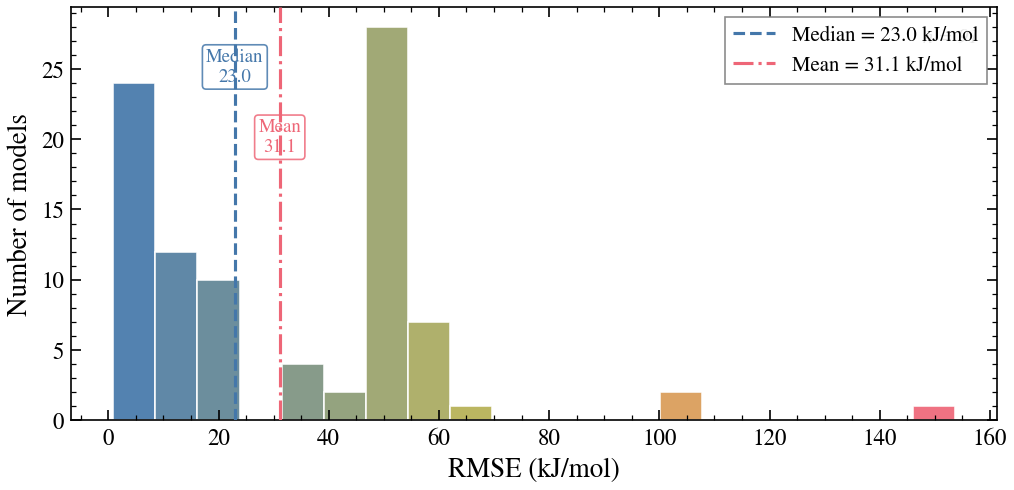

Saved: fig1_rmse_histogram.png / .pdf


In [12]:
# Fig. 1 — RMSE Distribution Histogram
%matplotlib inline
from matplotlib.colors import LinearSegmentedColormap

rmse_vals = df_stats['RMSE (kJ/mol)'].dropna()

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.5))

# Histogram with gradient colouring (colourblind-safe: blue → yellow → red)
n_vals, bins, patches = ax.hist(rmse_vals, bins=20, edgecolor='white', linewidth=0.8, alpha=0.92)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
norm_bins = plt.Normalize(bin_centers.min(), bin_centers.max())
cmap = LinearSegmentedColormap.from_list('rmse_cb', [CB_COLORS['blue'], CB_COLORS['yellow'], CB_COLORS['red']])
for c_val, p in zip(bin_centers, patches):
    p.set_facecolor(cmap(norm_bins(c_val)))

# Reference lines
ax.axvline(rmse_vals.median(), color=CB_COLORS['blue'], linestyle='--', linewidth=1.5,
           label=f'Median = {rmse_vals.median():.1f} kJ/mol', zorder=5)
ax.axvline(rmse_vals.mean(), color=CB_COLORS['red'], linestyle='-.', linewidth=1.5,
           label=f'Mean = {rmse_vals.mean():.1f} kJ/mol', zorder=5)

ax.set_xlabel('RMSE (kJ/mol)')
ax.set_ylabel('Number of models')
ax.legend(loc='upper right')

# Annotate median and mean
y_top = ax.get_ylim()[1]
ax.annotate(f'Median\n{rmse_vals.median():.1f}',
            xy=(rmse_vals.median(), y_top * 0.82), fontsize=9, ha='center',
            color=CB_COLORS['blue'],
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=CB_COLORS['blue'], alpha=0.85))
ax.annotate(f'Mean\n{rmse_vals.mean():.1f}',
            xy=(rmse_vals.mean(), y_top * 0.65), fontsize=9, ha='center',
            color=CB_COLORS['red'],
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=CB_COLORS['red'], alpha=0.85))

# n annotation
ax.text(0.98, 0.95, f'n = {len(rmse_vals)}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, style='italic')

plt.tight_layout()
fig.savefig('fig1_rmse_histogram.png', dpi=300)
fig.savefig('fig1_rmse_histogram.pdf')
plt.show()
print("Saved: fig1_rmse_histogram.png / .pdf")

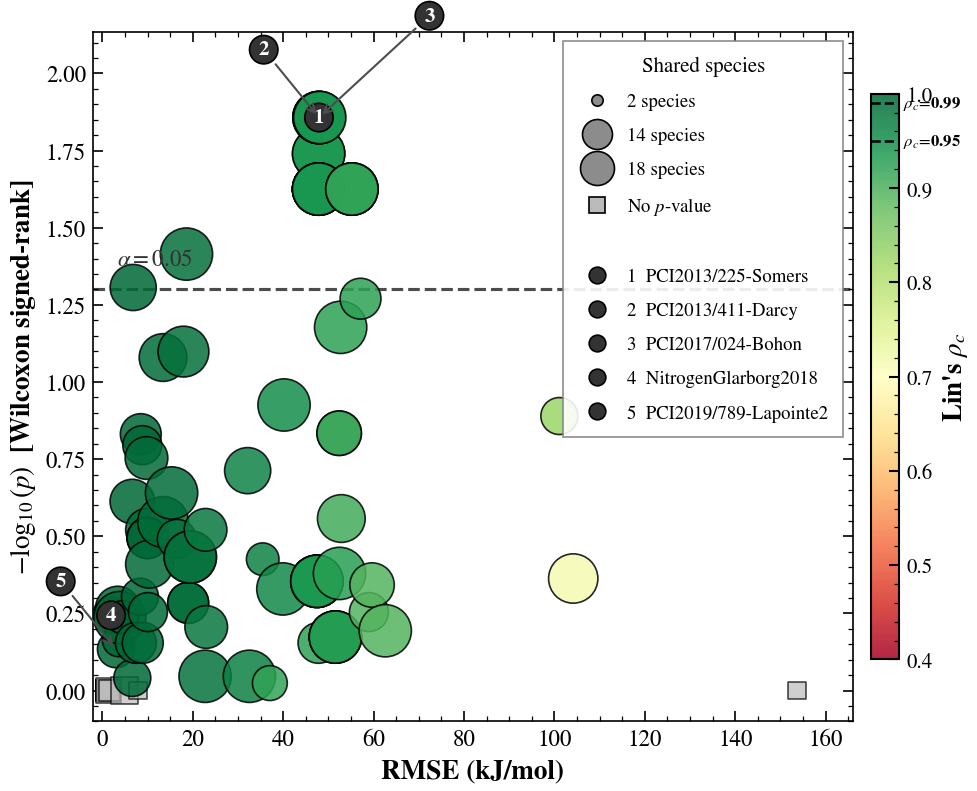

Saved: fig2_volcano_plot.png / .pdf


In [13]:
# Fig. 2 — Volcano Plot: RMSE vs −log₁₀(p) with Lin's ρ_c as colour
# Classic volcano layout: x = effect magnitude (RMSE), y = statistical significance
# Colour = Lin's concordance correlation coefficient (agreement quality)
# Size = number of shared species (dynamic from data)
# Notable models labelled by numeric index; index→name mapping in legend
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

plot_df = df_stats[df_stats['RMSE (kJ/mol)'].notna()].copy()

# −log₁₀(p) — y-axis
plot_df['neg_log_p'] = plot_df['Wilcoxon p-value'].apply(
    lambda p: -np.log10(p) if (pd.notna(p) and p > 0) else np.nan
)
has_p = plot_df['neg_log_p'].notna() & plot_df["Lin's CCC"].notna()
no_p  = ~plot_df['neg_log_p'].notna() & plot_df["Lin's CCC"].notna()

# --- Dynamic size scaling ---
SIZE_SCALE = 35
sp_vals = plot_df.loc[has_p | no_p, 'Shared Species']

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 5.5))

# --- Main scatter: colour = Lin's CCC ---
ccc_vals = plot_df.loc[has_p, "Lin's CCC"]
sc = ax.scatter(
    plot_df.loc[has_p, 'RMSE (kJ/mol)'],
    plot_df.loc[has_p, 'neg_log_p'],
    c=ccc_vals,
    cmap='RdYlGn',  # red (poor CCC) → green (excellent CCC)
    vmin=0.4, vmax=1.0,
    s=plot_df.loc[has_p, 'Shared Species'] * SIZE_SCALE,
    edgecolors='k', linewidth=0.8, alpha=0.85, zorder=3
)

# --- Colourbar for ρ_c ---
cbar = plt.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label(r"Lin's $\rho_c$", fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=10, width=1.0)
cbar.outline.set_linewidth(1.0)

# ρ_c threshold annotations on colourbar
for rho_thresh, lbl in [(0.95, '0.95'), (0.99, '0.99')]:
    if 0.4 <= rho_thresh <= 1.0:
        cbar.ax.axhline(rho_thresh, color='k', linestyle='--', linewidth=1.2)
        cbar.ax.text(1.15, rho_thresh, r'$\rho_c\!=\!$' + lbl,
                     transform=cbar.ax.get_yaxis_transform(),
                     fontsize=8, fontweight='bold', va='center', ha='left')

# --- Models with no p-value: place at y = 0 with distinct marker ---
if no_p.any():
    ax.scatter(
        plot_df.loc[no_p, 'RMSE (kJ/mol)'],
        np.zeros(no_p.sum()),  # placed at y = 0
        s=plot_df.loc[no_p, 'Shared Species'] * SIZE_SCALE,
        c=CB_COLORS['grey'], marker='s',
        edgecolors='k', linewidth=0.8, alpha=0.7, zorder=2,
    )

# --- Significance threshold: horizontal dashed line at α = 0.05 ---
p_thresh_y = -np.log10(0.05)
ax.axhline(p_thresh_y, color='k', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
ax.text(ax.get_xlim()[1] * 0.02, p_thresh_y + 0.06, r'$\alpha = 0.05$',
        fontsize=11, fontweight='bold', va='bottom', ha='left', color='0.2')

# --- Select notable models and assign numeric indices ---
# Top 3 by −log₁₀(p) (most significant)
top_sig = plot_df.loc[has_p].nlargest(3, 'neg_log_p')
# Top 2 by CCC (best agreement)
top_ccc = plot_df.loc[has_p].nlargest(2, "Lin's CCC")
# Combine, deduplicate
label_models = pd.concat([top_sig, top_ccc]).drop_duplicates(subset='Model').reset_index(drop=True)

# Place numeric index labels — offset overlapping annotations
# Collect raw positions and detect overlaps
raw_positions = []
for _, row in label_models.iterrows():
    raw_positions.append((row['RMSE (kJ/mol)'], row['neg_log_p']))

# Compute offsets: spread overlapping labels apart
x_range = plot_df['RMSE (kJ/mol)'].max() - plot_df['RMSE (kJ/mol)'].min()
y_range = plot_df.loc[has_p, 'neg_log_p'].max() - plot_df.loc[has_p, 'neg_log_p'].min()
offset_configs = []  # (dx, dy) offsets in data coords for the text position

for i, (x0, y0) in enumerate(raw_positions):
    # Check if this point is close to any previous point
    is_crowded = False
    for j, (xp, yp) in enumerate(raw_positions[:i]):
        if abs(x0 - xp) < x_range * 0.05 and abs(y0 - yp) < y_range * 0.08:
            is_crowded = True
            break
    if is_crowded:
        # Fan outward: alternate left/right with increasing vertical offset
        crowd_idx = sum(1 for j, (xp, yp) in enumerate(raw_positions[:i])
                        if abs(x0 - xp) < x_range * 0.05 and abs(y0 - yp) < y_range * 0.08)
        dx = x_range * 0.08 * (1 if crowd_idx % 2 == 0 else -1) * ((crowd_idx // 2) + 1)
        dy = y_range * 0.06 * (crowd_idx + 1)
        offset_configs.append((dx, dy))
    else:
        offset_configs.append((0, 0))  # no offset needed

for i, (_, row) in enumerate(label_models.iterrows()):
    dx, dy = offset_configs[i]
    x_data = row['RMSE (kJ/mol)']
    y_data = row['neg_log_p']

    if dx == 0 and dy == 0:
        # Place directly on the point
        ax.annotate(
            str(i + 1),
            xy=(x_data, y_data),
            fontsize=10, fontweight='bold', color='white', ha='center', va='center',
            bbox=dict(boxstyle='circle,pad=0.25', fc='0.2', ec='k', lw=0.8),
            zorder=5
        )
    else:
        # Place offset with arrow back to the data point
        ax.annotate(
            str(i + 1),
            xy=(x_data, y_data),
            xytext=(x_data + dx, y_data + dy),
            fontsize=10, fontweight='bold', color='white', ha='center', va='center',
            bbox=dict(boxstyle='circle,pad=0.25', fc='0.2', ec='k', lw=0.8),
            arrowprops=dict(arrowstyle='->', color='0.3', lw=1.0),
            zorder=5
        )

# --- Build combined legend: size guide + index→model mapping ---
# Size legend entries
legend_species = sorted(set([int(sp_vals.min()),
                             int(sp_vals.quantile(0.5)),
                             int(sp_vals.max())]))
legend_handles = [
    Line2D([], [], marker='o', color='none', markeredgecolor='k', markeredgewidth=0.8,
           markersize=np.sqrt(n_sp * SIZE_SCALE) * 0.65,
           label=f'{n_sp} species', markerfacecolor='0.55', linewidth=0)
    for n_sp in legend_species
]
legend_handles.append(
    Line2D([], [], marker='s', color='none', markeredgecolor='k', markeredgewidth=0.8,
           markersize=8, label='No $p$-value', markerfacecolor=CB_COLORS['grey'], linewidth=0)
)
# Separator
legend_handles.append(Line2D([], [], color='none', label=''))  # blank spacer

# Index → model name entries
for i, (_, row) in enumerate(label_models.iterrows(), 1):
    legend_handles.append(
        Line2D([], [], marker='o', color='none', markeredgecolor='k', markeredgewidth=0.8,
               markersize=8, markerfacecolor='0.2', linewidth=0,
               label=f'{i}  {row["Model"][:28]}')
    )

ax.legend(handles=legend_handles, loc='upper right', fontsize=9,
          title='Shared species', title_fontsize=10, handletextpad=0.6,
          borderpad=0.8, labelspacing=0.9)

# --- Axis labels ---
ax.set_xlabel('RMSE (kJ/mol)', fontsize=13, fontweight='bold')
ax.set_ylabel(r'$-\log_{10}(p)$  [Wilcoxon signed-rank]', fontsize=13, fontweight='bold')

# --- Axis limits ---
ax.set_xlim(left=-2, right=plot_df['RMSE (kJ/mol)'].max() * 1.08)
y_max = plot_df.loc[has_p, 'neg_log_p'].max()
ax.set_ylim(bottom=-0.1, top=y_max * 1.15)

plt.tight_layout()
fig.savefig('fig2_volcano_plot.png', dpi=300)
fig.savefig('fig2_volcano_plot.pdf')
plt.show()
print("Saved: fig2_volcano_plot.png / .pdf")

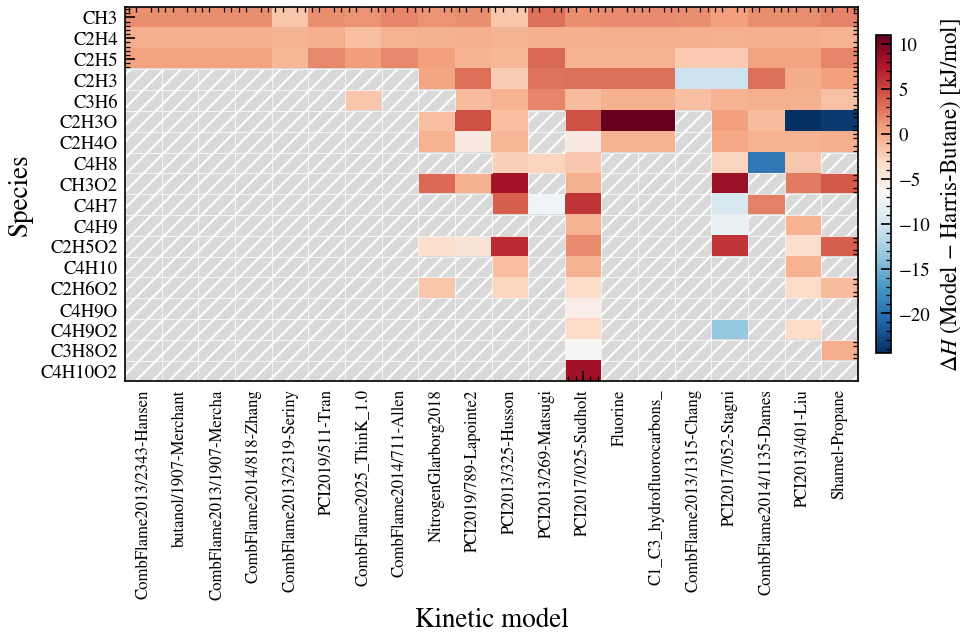

Saved: fig3_enthalpy_heatmap.png / .pdf


In [14]:
# Fig. 3 — Enthalpy Difference Heatmap (Species × Models)

top20 = df_stats[df_stats['Shared Species'] >= 3].head(20)['Model'].tolist()
diff_matrix = df_enthalpy_matrix[top20].subtract(df_enthalpy_matrix['Harris-Butane'], axis=0)
data = diff_matrix.values.astype(float)

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 4.5))

# Grey background for missing data
ax.set_facecolor('#d9d9d9')

masked_data = np.ma.masked_invalid(data)
im = ax.imshow(masked_data, aspect='auto', cmap='RdBu_r', interpolation='nearest')

# Hatched overlay for NaN cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isnan(data[i, j]):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                         fill=True, facecolor='#d9d9d9', edgecolor='white',
                         linewidth=0.3, hatch='///', zorder=2))

ax.set_xticks(range(len(top20)))
ax.set_xticklabels([m[:25] for m in top20], rotation=90, fontsize=8)
ax.set_yticks(range(len(diff_matrix.index)))
ax.set_yticklabels(diff_matrix.index, fontsize=9)

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label(r'$\Delta H$ (Model $-$ Harris-Butane) [kJ/mol]', fontsize=11)
cbar.ax.tick_params(labelsize=9)

ax.set_xlabel('Kinetic model')
ax.set_ylabel('Species')

# Turn off top/right ticks for heatmap (they look odd)
ax.tick_params(top=False, right=False)

plt.tight_layout()
fig.savefig('fig3_enthalpy_heatmap.png', dpi=300)
fig.savefig('fig3_enthalpy_heatmap.pdf')
plt.show()
print("Saved: fig3_enthalpy_heatmap.png / .pdf")

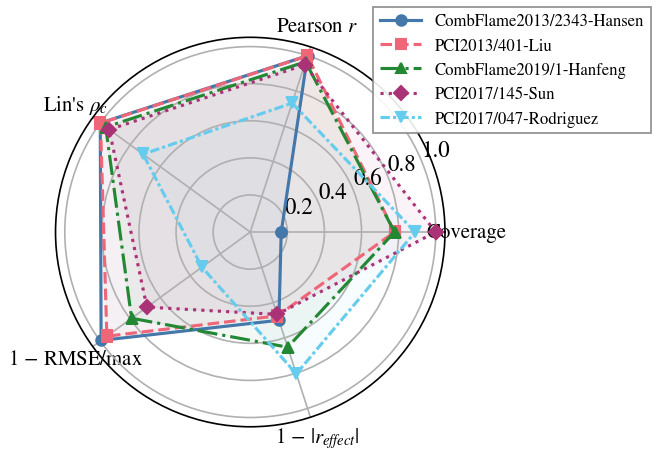

Saved: fig4_radar_chart.png / .pdf

Radar chart values (all scaled 0–1, higher = better):


,Model,Coverage,Pearson r,Lin's CCC,1−norm RMSE,1−|Effect r|
0,CombFlame2013/2343-Hansen,0.167,1.0000,0.9997,0.9941,NaN
1,PCI2013/401-Liu,0.778,0.9987,0.9984,0.9557,0.475
2,CombFlame2019/1-Hanfeng,0.778,0.9654,0.9633,0.7909,0.653
3,PCI2017/145-Sun,1.000,0.9476,0.9401,0.6887,0.467
4,PCI2017/047-Rodriguez,0.889,0.7312,0.7141,0.3221,0.804


In [15]:
# Fig. 4 — Radar Chart: Diverse Models Multi-Metric Comparison
from math import pi

candidates = df_stats[df_stats['Shared Species'] >= 3].copy()
picks = []

picks.append(candidates.iloc[0]['Model'])                # best RMSE
picks.append(candidates.iloc[-1]['Model'])                # worst RMSE
highest_cov = candidates.sort_values('Shared Species', ascending=False).iloc[0]['Model']
if highest_cov not in picks:
    picks.append(highest_cov)
sig_large = candidates[(candidates['Sig (p<0.05)'] == '✓') & (candidates['Effect'] == 'large')]
if not sig_large.empty and sig_large.iloc[0]['Model'] not in picks:
    picks.append(sig_large.iloc[0]['Model'])
mid_idx = len(candidates) // 2
if candidates.iloc[mid_idx]['Model'] not in picks:
    picks.append(candidates.iloc[mid_idx]['Model'])
for _, row in candidates.iterrows():
    if len(picks) >= 5:
        break
    if row['Model'] not in picks:
        picks.append(row['Model'])

radar_models = candidates[candidates['Model'].isin(picks)]

categories = ['Coverage', r'Pearson $r$', r"Lin's $\rho_c$", r'1 $-$ RMSE/max', r'1 $-$ |$r_{effect}$|']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)] + [0]
max_rmse = df_stats['RMSE (kJ/mol)'].max()

# Colourblind-safe palette + distinct markers/linestyles
radar_colors = [CB_COLORS['blue'], CB_COLORS['red'], CB_COLORS['green'],
                CB_COLORS['purple'], CB_COLORS['cyan']]
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
markers = ['o', 's', '^', 'D', 'v']

fig, ax = plt.subplots(figsize=(ONE_HALF_COL, ONE_HALF_COL), subplot_kw=dict(polar=True))

for idx, (_, row) in enumerate(radar_models.iterrows()):
    values = [
        row['Coverage (%)'] / 100,
        row['Pearson r'] if pd.notna(row['Pearson r']) else 0,
        row["Lin's CCC"] if pd.notna(row["Lin's CCC"]) else 0,
        1 - (row['RMSE (kJ/mol)'] / max_rmse) if pd.notna(row['RMSE (kJ/mol)']) else 0,
        1 - abs(row['Effect Size r']) if pd.notna(row['Effect Size r']) else 0.5,
    ]
    values += values[:1]
    ax.plot(angles, values, linewidth=1.5, linestyle=linestyles[idx],
            color=radar_colors[idx], label=row['Model'][:28],
            marker=markers[idx], markersize=5)
    ax.fill(angles, values, alpha=0.05, color=radar_colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', bbox_to_anchor=(1.55, 1.1), fontsize=8, handlelength=2.5)

plt.tight_layout()
fig.savefig('fig4_radar_chart.png', dpi=300)
fig.savefig('fig4_radar_chart.pdf')
plt.show()
print("Saved: fig4_radar_chart.png / .pdf")

# Table of underlying values
print("\nRadar chart values (all scaled 0–1, higher = better):")
radar_rows = []
for _, row in radar_models.iterrows():
    radar_rows.append({
        'Model': row['Model'][:30],
        'Coverage': round(row['Coverage (%)'] / 100, 3),
        'Pearson r': round(row['Pearson r'], 4) if pd.notna(row['Pearson r']) else None,
        "Lin's CCC": round(row["Lin's CCC"], 4) if pd.notna(row["Lin's CCC"]) else None,
        '1−norm RMSE': round(1 - row['RMSE (kJ/mol)'] / max_rmse, 4) if pd.notna(row['RMSE (kJ/mol)']) else None,
        '1−|Effect r|': round(1 - abs(row['Effect Size r']), 3) if pd.notna(row['Effect Size r']) else None,
    })
display(pd.DataFrame(radar_rows))

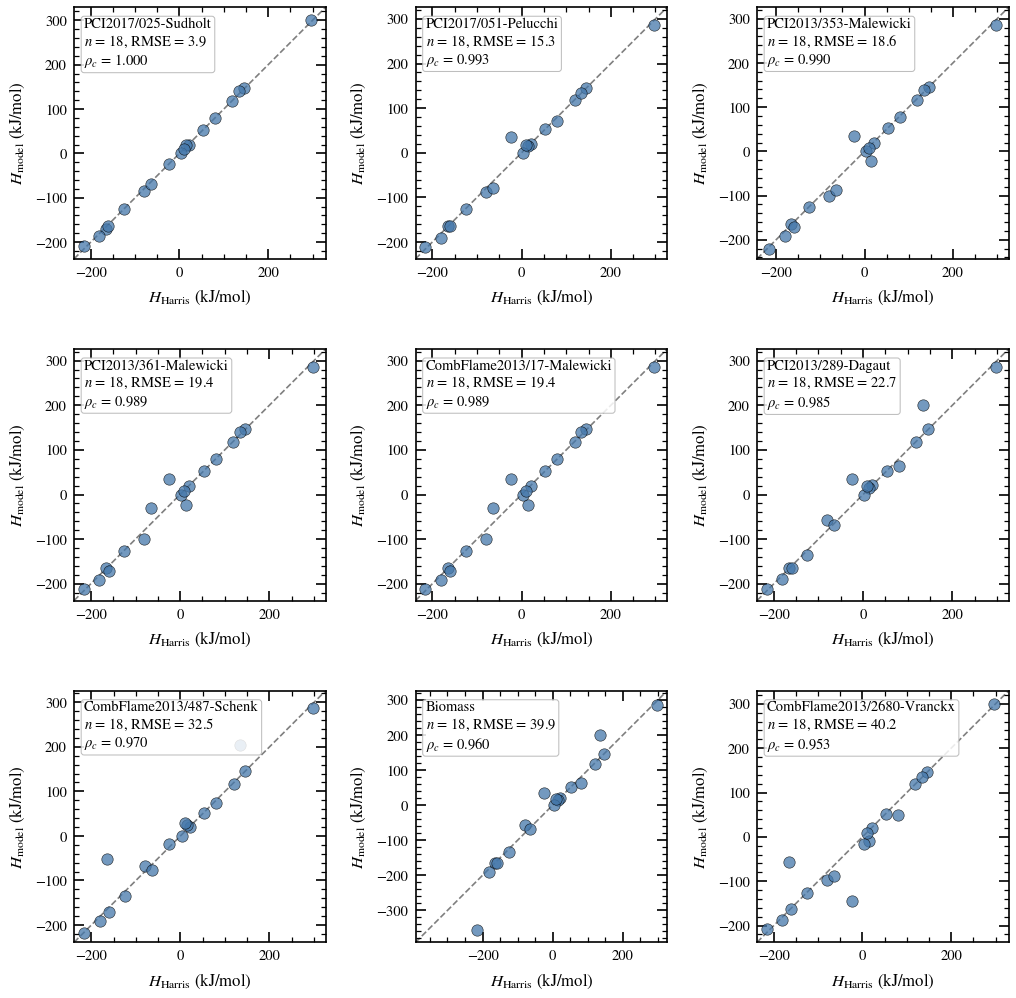

Saved: fig5_parity_plots.png / .pdf


In [16]:
# Fig. 5 — Parity Plots: Top 9 models vs Harris-Butane
%matplotlib inline

top_models = df_stats[df_stats['Shared Species'] >= 3].sort_values(
    ['Shared Species', 'RMSE (kJ/mol)'], ascending=[False, True]
).head(9)

fig, axes = plt.subplots(3, 3, figsize=(DOUBLE_COL, DOUBLE_COL))

for idx, (_, row) in enumerate(top_models.iterrows()):
    ax = axes[idx // 3, idx % 3]
    model_name = row['Model']

    mask = harris_values.notna() & df_enthalpy_matrix[model_name].notna()
    h_vals = harris_values[mask].values.astype(float)
    m_vals = df_enthalpy_matrix[model_name][mask].values.astype(float)

    ax.scatter(h_vals, m_vals, s=30, alpha=0.75, c=CB_COLORS['blue'],
               edgecolors='k', linewidth=0.3, zorder=3)

    # y = x reference line
    all_vals = np.concatenate([h_vals, m_vals])
    lim_min, lim_max = all_vals.min() * 1.1, all_vals.max() * 1.1
    if lim_min > 0:
        lim_min *= 0.9
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.5, linewidth=0.8, label='$y = x$')
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.set_xlabel(r'$H_\mathrm{Harris}$ (kJ/mol)', fontsize=8)
    ax.set_ylabel(r'$H_\mathrm{model}$ (kJ/mol)', fontsize=8)
    ccc_val = row["Lin's CCC"]
    n_sp = int(row['Shared Species'])
    if ccc_val is not None:
        ax.text(0.04, 0.96,
                f"{model_name[:28]}\n$n$ = {n_sp}, RMSE = {row['RMSE (kJ/mol)']:.1f}\n$\\rho_c$ = {ccc_val:.3f}",
                transform=ax.transAxes, fontsize=7, va='top',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.85, lw=0.5))
    else:
        ax.text(0.04, 0.96, f"{model_name[:28]}\n$n$ = {n_sp}",
                transform=ax.transAxes, fontsize=7, va='top',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.7', alpha=0.85, lw=0.5))
    ax.tick_params(labelsize=7)
    ax.set_aspect('equal', adjustable='box')

for idx in range(len(top_models), 9):
    axes[idx // 3, idx % 3].set_visible(False)

plt.tight_layout()
fig.savefig('fig5_parity_plots.png', dpi=300)
fig.savefig('fig5_parity_plots.pdf')
display(fig)
plt.close(fig)
print("Saved: fig5_parity_plots.png / .pdf")

In [17]:
# Get a dictionary of models with their corresponding species thermochemistry from species_thermo_model_dict
model_species_thermo_dict = {}
for species, models in species_thermo_model_dict.items():
    for model in models:
        if model not in model_species_thermo_dict:
            model_species_thermo_dict[model] = []
        model_species_thermo_dict[model].append(species)
print(f"Models with the same species in harris model:==> {len(model_species_thermo_dict)}")
model_species_thermo_dict

Models with the same species in harris model:==> 99


{'n-Heptane': ['C4H10',
  'C2H4',
  'C3H6',
  'CH3',
  'C2H3O',
  'C2H3',
  'C2H5',
  'C2H4O',
  'CH3O2',
  'C2H5O2',
  'C2H6O2',
  'C4H9',
  'C4H9O2',
  'C4H10O2',
  'C4H8',
  'C4H7',
  'C4H9O',
  'C3H8O2',
  'O2',
  'HO2',
  'C2H2O',
  'H2O2',
  'H',
  'H2',
  'CH4',
  'HO',
  'H2O',
  'O',
  'C3H5',
  'C4H9O4',
  'CH4O2',
  'C4H8O3',
  'C4H9O3',
  'C3H7O2',
  'C4H7O2',
  'C3H4'],
 'AramcoMech_1.3': ['C4H10',
  'C2H4',
  'C3H6',
  'CH3',
  'C2H3O',
  'C2H3',
  'C2H5',
  'C2H4O',
  'CH3O2',
  'C2H5O2',
  'C2H6O2',
  'C4H9',
  'C4H9O2',
  'C4H10O2',
  'C4H8',
  'C4H7',
  'C4H9O',
  'C3H8O2',
  'O2',
  'HO2',
  'C2H2O',
  'H2O2',
  'H',
  'H2',
  'CH4',
  'HO',
  'H2O',
  'O',
  'C3H5',
  'C4H9O4',
  'CH4O2',
  'C4H8O3',
  'C4H9O3',
  'C3H7O2',
  'C4H7O2',
  'C3H4'],
 '2-BTP': ['C4H10',
  'C2H4',
  'C3H6',
  'CH3',
  'C2H3O',
  'C2H3',
  'C2H5',
  'C2H4O',
  'C4H9',
  'C4H8',
  'C4H7',
  'O2',
  'HO2',
  'C2H2O',
  'H2O2',
  'H',
  'H2',
  'CH4',
  'HO',
  'H2O',
  'O',
  'C3H5',
  'C3H

In [18]:
# =============================================================================
# Helper functions for RMG thermo library export
# (called by the unified library export cell below)
# =============================================================================

import os, re
from rmgpy.thermo import NASA as rmg_NASA, NASAPolynomial as rmg_NASAPolynomial

def sanitise_filename(name):
    """Replace filesystem-unsafe characters with underscores."""
    return re.sub(r'[/\\:*?"<>|]', '_', name)


def db_thermo_to_rmg_nasa(thermo):
    """
    Convert a database Thermo object (Django model) to an rmgpy.thermo.NASA
    object so that repr() produces the canonical RMG format.
    """
    poly_low = rmg_NASAPolynomial(
        coeffs=thermo.coeffs_poly1,
        Tmin=(thermo.temp_min_1, 'K'),
        Tmax=(thermo.temp_max_1, 'K'),
    )
    poly_high = rmg_NASAPolynomial(
        coeffs=thermo.coeffs_poly2,
        Tmin=(thermo.temp_min_2, 'K'),
        Tmax=(thermo.temp_max_2, 'K'),
    )
    nasa = rmg_NASA(
        polynomials=[poly_low, poly_high],
        Tmin=(thermo.temp_min_1, 'K'),
        Tmax=(thermo.temp_max_2, 'K'),
    )
    return nasa


def save_entry(f, index, label, adj_list, nasa, short_desc, long_desc):
    """
    Write a single thermo entry in the canonical RMG format.
    Mirrors rmgpy.data.thermo.save_entry().
    """
    f.write('entry(\n')
    f.write('    index = {0:d},\n'.format(index))
    f.write('    label = "{0}",\n'.format(label))

    if adj_list:
        f.write('    molecule = \n')
        f.write('"""\n')
        f.write(adj_list)
        if not adj_list.endswith('\n'):
            f.write('\n')
        f.write('""",\n')

    # NASA thermo block — use repr() on the polynomials (canonical RMG output)
    f.write('    thermo = NASA(\n')
    f.write('        polynomials = [\n')
    for poly in nasa.polynomials:
        f.write('            {0!r},\n'.format(poly))
    f.write('        ],\n')
    if nasa.Tmin is not None:
        f.write('        Tmin = {0!r},\n'.format(nasa.Tmin))
    if nasa.Tmax is not None:
        f.write('        Tmax = {0!r},\n'.format(nasa.Tmax))
    if nasa.E0 is not None:
        f.write('        E0 = {0!r},\n'.format(nasa.E0))
    if nasa.Cp0 is not None:
        f.write('        Cp0 = {0!r},\n'.format(nasa.Cp0))
    if nasa.CpInf is not None:
        f.write('        CpInf = {0!r},\n'.format(nasa.CpInf))
    f.write('    ),\n')

    f.write('    shortDesc = """{0}""",\n'.format(short_desc.strip()))
    f.write('    longDesc = \n"""\n{0}\n""",\n'.format(long_desc.strip()))
    f.write(')\n\n')


def write_thermo_library(model_name, formulas, output_filepath):
    """
    Query all thermo entries for `model_name` that match the given
    formulas and write an RMG-Py-style ThermoLibrary.py file to
    the specified filepath.

    Parameters
    ----------
    model_name : str
        Name of the kinetic model in the database.
    formulas : iterable of str
        Chemical formulas to include (only species with thermo data).
    output_filepath : str
        Full path for the output .py file (e.g. .../model_dir/ThermoLibrary.py).

    Returns
    -------
    int : number of thermo entries written.
    """
    model = KineticModel.objects.get(model_name=model_name)

    entries = []

    for formula in sorted(formulas):
        # Get thermo entries for this species in this model
        thermo_qs = model.thermo.filter(
            species__isomers__formula__formula=formula
        ).distinct()

        if not thermo_qs.exists():
            continue

        thermo = thermo_qs.first()
        species = thermo.species

        # Label: use formula to stay consistent with dictionary.txt and reactions.py
        # (both use formula as the species identifier)
        label = formula

        # Keep the model-specific species name for the comment
        sn = species.speciesname_set.filter(kinetic_model=model).first()
        species_name = sn.name if sn and sn.name else formula

        # Adjacency list
        structures = species.structures
        adj_list = structures.first().adjacency_list if structures.exists() else None

        # Convert to RMG NASA object
        nasa = db_thermo_to_rmg_nasa(thermo)

        # Comment
        tc = ThermoComment.objects.filter(thermo=thermo, kinetic_model=model).first()
        short_desc = tc.comment.strip() if tc and tc.comment else ''
        long_desc = (f'Formula: {formula}\n'
                     f'Species name in model: {species_name}\n'
                     f'_auto-generated from kinetic-models database.')

        entries.append((label, adj_list, nasa, short_desc, long_desc))

    if not entries:
        return 0

    with open(output_filepath, 'w') as f:
        f.write('#!/usr/bin/env python\n')
        f.write('# encoding: utf-8\n\n')
        f.write('name = "{0}"\n'.format(model_name))
        f.write('shortDesc = "Thermo library for species appearing in shared reactions with Harris-Butane"\n')
        f.write('longDesc = """\n')
        f.write('Thermo entries from model {0}\n'.format(model_name))
        f.write('filtered to species that participate in reactions shared with Harris-Butane.\n')
        f.write('Auto-generated from the kinetic-models database.\n')
        f.write('"""\n')

        for entry_idx, (label, adj_list, nasa, short_desc, long_desc) in enumerate(entries):
            save_entry(f, entry_idx, label, adj_list, nasa, short_desc, long_desc)

    return len(entries)


print("Thermo library helper functions defined:")
print("  sanitise_filename(), db_thermo_to_rmg_nasa(), save_entry(), write_thermo_library()")

Thermo library helper functions defined:
  sanitise_filename(), db_thermo_to_rmg_nasa(), save_entry(), write_thermo_library()


In [19]:
# Harris model kinetics
# harris_kinetics = harris_model.kinetics.all()

harris_kinetics = KineticsComment.objects.filter(kinetic_model=harris_model)
for reaction in harris_kinetics:
    reaction = reaction.kinetics.reaction
    # print(reaction.equation)

len(harris_kinetics)

42

In [20]:
# Find models sharing the EXACT SAME Kinetics database entry
# This means they literally use the same kinetics record (same A, n, Ea)
# Deduplicate: one row per unique reaction equation, aggregating all models

from collections import defaultdict

# Step 1: Build mapping: Kinetics ID → set of model names
kinetics_to_models = defaultdict(set)
for kc in KineticsComment.objects.select_related('kinetics__reaction').all():
    kinetics_to_models[kc.kinetics.pk].add(kc.kinetic_model.model_name)

# Step 2: Keep only kinetics entries shared by >1 model
# Then deduplicate by reaction equation — aggregate models across all
# Kinetics IDs that map to the same equation
reaction_to_info = {}  # equation → {models, kinetics_ids, type, A, n, Ea}

for kinetics_id, models in kinetics_to_models.items():
    if len(models) < 2:
        continue

    kinetics = Kinetics.objects.select_related('reaction').get(pk=kinetics_id)
    equation = kinetics.reaction.equation
    raw = kinetics.raw_data

    if equation not in reaction_to_info:
        A = raw.get('a_si') if raw.get('type') == 'arrhenius' else None
        n = raw.get('n') if raw.get('type') == 'arrhenius' else None
        Ea = raw.get('e_si') if raw.get('type') == 'arrhenius' else None
        reaction_to_info[equation] = {
            'models': set(),
            'kinetics_ids': [],
            'type': raw.get('type'),
            'A': A, 'n': n, 'Ea': Ea,
        }

    reaction_to_info[equation]['models'].update(models)
    reaction_to_info[equation]['kinetics_ids'].append(kinetics_id)

# Step 3: Build DataFrame — one row per unique reaction equation
shared_kinetics_data = []
for equation, info in reaction_to_info.items():
    shared_kinetics_data.append({
        'Reaction': equation[:60] + '...' if len(equation) > 60 else equation,
        'Type': info['type'],
        'A (SI)': f"{info['A']:.2e}" if info['A'] else None,
        'n': info['n'],
        'Ea (J/mol)': info['Ea'],
        'Kinetics IDs': len(info['kinetics_ids']),
        'Shared By': ', '.join(sorted(info['models'])),
        'Model Count': len(info['models']),
    })

df_shared_kinetics = pd.DataFrame(shared_kinetics_data)
if not df_shared_kinetics.empty:
    df_shared_kinetics = df_shared_kinetics.sort_values('Model Count', ascending=False)

print(f"Found {len(df_shared_kinetics)} unique reactions shared by multiple models")
print(f"  (aggregated from {sum(len(v['kinetics_ids']) for v in reaction_to_info.values())} kinetics entries)")
df_shared_kinetics

Found 8760 unique reactions shared by multiple models
  (aggregated from 26825 kinetics entries)


,Reaction,Type,A (SI),n,Ea (J/mol),Kinetics IDs,Shared By,Model Count
2508,O + H2 <=> H + HO,arrhenius,8.10e+07,0.00,0.00000,10,"2-BTP, AramcoMech_1.3, AramcoMech_2.0, Biomass...",76
4,H2O2 + O <=> HO + HO2,arrhenius,9.63e+00,2.00,16736.00000,8,"2-BTP, AramcoMech_1.3, AramcoMech_2.0, Biomass...",76
6,CH4 + HO <=> H2O + CH3,arrhenius,1.00e+02,1.60,13054.08000,9,"2-BTP, AramcoMech_1.3, AramcoMech_2.0, Biomass...",75
308,CH4 + H <=> H2 + CH3,arrhenius,5.47e+01,1.97,46902.64000,8,"2-BTP, AramcoMech_1.3, AramcoMech_2.0, Biomass...",75
60,H2O2 + H <=> HO + H2O,arrhenius,2.41e+07,0.00,16610.48000,4,"2-BTP, AramcoMech_1.3, AramcoMech_2.0, Biomass...",74
...,...,...,...,...,...,...,...,...
6406,C4H8O + C3H3 -> CHO + C3H6 + C3H4,arrhenius,4.05e-02,2.00,61632.83040,1,"Biomass, PCI2013/289-Dagaut",2
6407,C4H8O + C2H3O3 -> CHO + C3H6 + C2H4O3,arrhenius,5.10e-02,2.00,26194.22488,1,"Biomass, PCI2013/289-Dagaut",2
3337,C9H7 + C3H8O -> C3H7O + C9H8,arrhenius,1.35e-02,2.00,79603.11040,6,"Biomass, PCI2013/289-Dagaut",2
6415,C7H7 + C6H12 -> C2H5 + C4H6 + C7H8,arrhenius,8.93e-02,2.00,-465.38632,1,"Biomass, PCI2013/289-Dagaut",2


In [21]:
# Find all models that share the same reactions as Harris-Butane
# Match by reaction EQUATION, deduplicate by unique kinetics entry
# Models sharing the exact same DB kinetics record are aggregated into one row
# Supports ALL kinetics types (arrhenius, troe, lindemann, third_body, multi_arrhenius, etc.)

import pandas as pd
import numpy as np
from collections import defaultdict

R = 8.314  # J/(mol·K)
TEMP_COMPARE = 1000  # K
PRESSURE = 101325  # Pa (1 atm) - needed for pressure-dependent types

def safe_get_rate_constant(kinetics_obj, T=TEMP_COMPARE):
    """
    Evaluate rate constant k(T) for any kinetics type using RMG.
    Returns (k_value, kinetics_type) or (None, kinetics_type) on failure.
    """
    raw = kinetics_obj.raw_data
    ktype = raw.get('type', 'unknown')
    try:
        rmg_rxn = kinetics_obj.to_rmg()
        rmg_kinetics = rmg_rxn.kinetics
        k = rmg_kinetics.get_rate_coefficient(T, PRESSURE)
        return (float(k), ktype)
    except Exception:
        pass
    # Fallback: manual Arrhenius
    if ktype == 'arrhenius':
        A = raw.get('a_si')
        n = raw.get('n')
        Ea = raw.get('e_si')
        if A is not None and n is not None and Ea is not None:
            try:
                k = A * (T ** n) * np.exp(-Ea / (R * T))
                return (float(k), ktype)
            except (OverflowError, FloatingPointError):
                pass
    # Fallback: manual multi_arrhenius (sum of individual Arrhenius rates)
    if ktype == 'multi_arrhenius':
        arr_set = raw.get('arrhenius_set', [])
        if arr_set:
            try:
                k_total = sum(
                    a['a_si'] * (T ** a['n']) * np.exp(-a['e_si'] / (R * T))
                    for a in arr_set
                    if a.get('a_si') is not None and a.get('n') is not None and a.get('e_si') is not None
                )
                return (float(k_total), ktype)
            except (OverflowError, FloatingPointError):
                pass
    return (None, ktype)

def get_arrhenius_params(raw):
    """Extract A, n, Ea for simple arrhenius; for others return the high-pressure or first set."""
    ktype = raw.get('type', 'unknown')
    if ktype == 'arrhenius':
        return raw.get('a_si'), raw.get('n'), raw.get('e_si')
    elif ktype in ('troe', 'lindemann'):
        high = raw.get('high_arrhenius', {})
        return high.get('a_si'), high.get('n'), high.get('e_si')
    elif ktype == 'third_body':
        low = raw.get('low_arrhenius', {})
        return low.get('a_si'), low.get('n'), low.get('e_si')
    elif ktype == 'multi_arrhenius':
        arr_set = raw.get('arrhenius_set', [])
        if arr_set:
            return arr_set[0].get('a_si'), arr_set[0].get('n'), arr_set[0].get('e_si')
    return None, None, None

# Step 1: Get all Harris reactions keyed by equation
harris_reactions = {}
for kc in KineticsComment.objects.filter(kinetic_model=harris_model).select_related('kinetics__reaction'):
    kinetics = kc.kinetics
    equation = kinetics.reaction.equation
    raw = kinetics.raw_data
    if equation not in harris_reactions:
        harris_k, harris_type = safe_get_rate_constant(kinetics)
        A, n, Ea = get_arrhenius_params(raw)
        harris_reactions[equation] = {
            'kinetics_id': kinetics.pk,
            'type': raw.get('type'),
            'k': harris_k,
            'A': A, 'n': n, 'Ea': Ea,
        }


# Step 2: Build per-kinetics-entry records, collecting models that share each entry
# Key: kinetics PK → {equation, model_names, computed values}
kinetics_entry_info = {}  # kinetics_pk → dict

for model in KineticModel.objects.exclude(model_name='Harris-Butane'):
    seen_eq = set()  # track (equation) per model to avoid counting one model twice for same equation
    for kc in KineticsComment.objects.filter(kinetic_model=model).select_related('kinetics__reaction'):
        kinetics = kc.kinetics
        equation = kinetics.reaction.equation
        
        if equation not in harris_reactions:
            continue
        if equation in seen_eq:
            continue
        seen_eq.add(equation)
        
        k_pk = kinetics.pk
        
        if k_pk not in kinetics_entry_info:
            # First time seeing this kinetics entry — compute values
            raw = kinetics.raw_data
            model_k, model_type = safe_get_rate_constant(kinetics)
            model_A, model_n, model_Ea = get_arrhenius_params(raw)
            harris = harris_reactions[equation]
            harris_k = harris['k']
            
            k_ratio = model_k / harris_k if (harris_k and model_k and harris_k != 0) else None
            log_k_ratio = np.log10(abs(k_ratio)) if k_ratio and k_ratio > 0 else None
            A_ratio = model_A / harris['A'] if (harris['A'] and model_A and harris['A'] != 0) else None
            n_diff = (model_n - harris['n']) if (model_n is not None and harris['n'] is not None) else None
            Ea_diff = (model_Ea - harris['Ea']) if (model_Ea is not None and harris['Ea'] is not None) else None
            
            kinetics_entry_info[k_pk] = {
                'equation': equation,
                'harris_type': harris['type'],
                'model_type': model_type,
                'harris_k': harris_k,
                'model_k': model_k,
                'k_ratio': k_ratio,
                'log_k_ratio': log_k_ratio,
                'A_ratio': A_ratio,
                'n_diff': n_diff,
                'Ea_diff': Ea_diff,
                'models': set(),
            }
        
        kinetics_entry_info[k_pk]['models'].add(model.model_name)

# Step 3: Further deduplicate — group entries with identical (equation + parameters)
# Some reactions have multiple kinetics DB entries with the exact same values
reaction_param_groups = defaultdict(lambda: {'models': set(), 'info': None})

for k_pk, info in kinetics_entry_info.items():
    # Build a key from the reaction + computed values
    group_key = (
        info['equation'],
        info['model_type'],
        f"{info['model_k']:.6e}" if info['model_k'] else None,
        round(info['n_diff'], 6) if info['n_diff'] is not None else None,
        round(info['Ea_diff'], 2) if info['Ea_diff'] is not None else None,
    )
    reaction_param_groups[group_key]['models'].update(info['models'])
    if reaction_param_groups[group_key]['info'] is None:
        reaction_param_groups[group_key]['info'] = info

# Step 4: Build final DataFrame — one row per unique (reaction, parameter set)
comparison_data = []
for group_key, group in reaction_param_groups.items():
    info = group['info']
    models = sorted(group['models'])
    equation = info['equation']
    
    comparison_data.append({
        'Reaction': equation[:70] + '...' if len(equation) > 70 else equation,
        'Harris Type': info['harris_type'],
        'Model Type': info['model_type'],
        f'Harris k({TEMP_COMPARE}K)': f"{info['harris_k']:.3e}" if info['harris_k'] else None,
        f'Model k({TEMP_COMPARE}K)': f"{info['model_k']:.3e}" if info['model_k'] else None,
        'k Ratio': f"{info['k_ratio']:.4f}" if info['k_ratio'] else None,
        'log10(k Ratio)': round(info['log_k_ratio'], 3) if info['log_k_ratio'] is not None else None,
        'A Ratio': f"{info['A_ratio']:.4f}" if info['A_ratio'] else None,
        'n Diff': round(info['n_diff'], 4) if info['n_diff'] is not None else None,
        'Ea Diff (kJ/mol)': round(info['Ea_diff'] / 1000, 2) if info['Ea_diff'] is not None else None,
        'Models': ', '.join(models),
        'Model Count': len(models),
    })

df_kinetics_compare = pd.DataFrame(comparison_data)

if not df_kinetics_compare.empty and 'log10(k Ratio)' in df_kinetics_compare.columns:
    df_kinetics_compare['Abs log k'] = df_kinetics_compare['log10(k Ratio)'].abs()
    df_kinetics_compare = df_kinetics_compare.sort_values('Abs log k', ascending=False, na_position='last').drop(columns='Abs log k')

df_kinetics_compare

,Reaction,Harris Type,Model Type,Harris k(1000K),Model k(1000K),k Ratio,log10(k Ratio),A Ratio,n Diff,Ea Diff (kJ/mol),Models,Model Count
11,C4H9 + O2 <=> HO2 + C4H8,arrhenius,arrhenius,3.360e-04,1.615e-25,0.0000,-21.318,0.0000,-3.0310,-176.38,"CombFlame2013/17-Malewicki, MB-Dooley, PCI2013...",5
53,C4H9 + O2 <=> HO2 + C4H8,arrhenius,arrhenius,3.360e-04,3.644e+05,1084540221.3997,9.035,182318729.6031,-3.0310,-188.91,"CombFlame2013/487-Schenk, PCI2015/0325-Nawdiyal",2
28,C4H9 + O2 <=> HO2 + C4H8,arrhenius,arrhenius,3.360e-04,2.700e+05,803546730.5676,8.905,49226056.9928,-3.0310,-197.30,"2-BTP, CombFlame2013/1609-Veloo, CombFlame2014...",7
60,C4H9 + O2 <=> HO2 + C4H8,arrhenius,arrhenius,3.360e-04,2.262e+05,673099558.4525,8.828,510492442.8887,-3.0310,-176.38,PCI2017/047-Rodriguez,1
101,C4H9 + O2 <=> HO2 + C4H8,arrhenius,arrhenius,3.360e-04,1.050e+05,312510509.2815,8.495,237014348.4840,-3.0310,-176.38,PCI2013/297-Herbinet,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4,C4H10 + H <=> H2 + C4H9,arrhenius,arrhenius,3.361e+06,4.344e+06,1.2923,0.111,0.0005,0.9629,-9.40,"CombFlame2013/1541-Zhang, CombFlame2013/17-Mal...",10
49,C4H10 + H <=> H2 + C4H9,arrhenius,arrhenius,3.361e+06,4.344e+06,1.2922,0.111,0.0005,0.9629,-9.40,PCI2017/025-Sudholt,1
102,C4H10 + H <=> H2 + C4H9,arrhenius,multi_arrhenius,3.361e+06,2.637e+06,0.7846,-0.105,0.0118,0.5629,4.11,PCI2013/297-Herbinet,1
41,C4H9O4 <=> HO + C4H8O3,arrhenius,arrhenius,1.797e+06,1.577e+06,0.8778,-0.057,2.9918,-0.4389,-15.01,PCI2013/401-Liu,1


In [22]:
# =============================================================================
# RMG library export: thermo + kinetics in the same per-model directory
# ─────────────────────────────────────────────────────────────────────────────
# For each qualifying model (shares BOTH thermo species AND reactions with
# Harris-Butane), create:
#     analysis/model_libraries/{model_name}/
#         ├── ThermoLibrary.py   (only species that appear in shared reactions)
#         ├── reactions.py       (shared reactions in canonical RMG entry format)
#         └── dictionary.txt     (adjacency lists for reaction species)
#
# Filter thermo by only formulas that participate in the model's
# shared reactions are included, not all Harris-formula-matching species.
# =============================================================================

import os, re
from collections import defaultdict

MODEL_LIBRARIES_DIR = os.path.join(PROJECT_ROOT, 'analysis', 'model_libraries')
os.makedirs(MODEL_LIBRARIES_DIR, exist_ok=True)

# ── Step 1: Identify Harris-Butane's reaction equations ──────────────────────
harris_equations = set()
for kc in KineticsComment.objects.filter(kinetic_model=harris_model).select_related('kinetics__reaction'):
    harris_equations.add(kc.kinetics.reaction.equation)

# ── Step 2: Find models with shared thermo AND shared kinetics ───────────────
model_matching_rxns = defaultdict(set)
for model in KineticModel.objects.exclude(model_name='Harris-Butane'):
    for kc in KineticsComment.objects.filter(kinetic_model=model).select_related('kinetics__reaction'):
        eq = kc.kinetics.reaction.equation
        if eq in harris_equations:
            model_matching_rxns[model.model_name].add(eq)

qualifying_models = {}
for model_name in sorted(model_species_thermo_dict.keys()):
    if model_name == 'Harris-Butane':
        continue
    shared_formulas = model_species_thermo_dict.get(model_name, [])
    shared_rxns = model_matching_rxns.get(model_name, set())
    if shared_formulas and shared_rxns:
        qualifying_models[model_name] = {
            'shared_formulas': shared_formulas,
            'shared_rxns': shared_rxns,
        }


for i, (mn, info) in enumerate(sorted(qualifying_models.items(),
                                       key=lambda x: len(x[1]['shared_rxns']),
                                       reverse=True)[:10], 1):
    print(f"  {i:2d}. {mn[:40]:40s}  thermo: {len(info['shared_formulas']):2d} species, "
          f"kinetics: {len(info['shared_rxns']):2d} reactions")


   1. CombFlame2013/2680-Vranckx                thermo: 36 species, kinetics: 16 reactions
   2. Biomass                                   thermo: 35 species, kinetics: 10 reactions
   3. PCI2013/289-Dagaut                        thermo: 34 species, kinetics: 10 reactions
   4. CombFlame2013/1609-Veloo                  thermo: 32 species, kinetics:  9 reactions
   5. CombFlame2013/487-Schenk                  thermo: 33 species, kinetics:  9 reactions
   6. CombFlame2014/798-Cai                     thermo: 35 species, kinetics:  9 reactions
   7. PCI2013/297-Herbinet                      thermo: 33 species, kinetics:  9 reactions
   8. PCI2015/0325-Nawdiyal                     thermo: 33 species, kinetics:  9 reactions
   9. PCI2017/037-Sakai                         thermo: 36 species, kinetics:  9 reactions
  10. PCI2017/051-Pelucchi                      thermo: 35 species, kinetics:  9 reactions


In [23]:
# ── Step 3: Kinetics library writer (returns reaction-participating formulas) ─

def write_kinetics_library(model_name, shared_rxn_equations, lib_dir):
    """
    Write an RMG-Py kinetics library (reactions.py + dictionary.txt) for a model,
    containing only reactions whose equation matches a Harris-Butane reaction.

    Returns
    -------
    n_rxns : int
    n_species : int
    rxn_formulas : set of str — formulas of all species participating in exported reactions
    """
    model = KineticModel.objects.get(model_name=model_name)

    entries = []
    all_species = {}        # formula → adjacency_list (for dictionary.txt)
    rxn_formulas = set()    # formulas appearing in shared reactions
    seen_equations = set()

    for kc in KineticsComment.objects.filter(kinetic_model=model).select_related(
        'kinetics__reaction'
    ):
        kinetics_obj = kc.kinetics
        equation = kinetics_obj.reaction.equation

        if equation not in shared_rxn_equations:
            continue
        if equation in seen_equations:
            continue
        seen_equations.add(equation)

        # Get the RMG reaction object with kinetics
        try:
            rmg_rxn = kinetics_obj.to_rmg()
        except Exception:
            continue

        rmg_kinetics = rmg_rxn.kinetics
        kinetics_repr = repr(rmg_kinetics)

        # Collect species for dictionary AND track their formulas for thermo filtering
        for species in kinetics_obj.reaction.reactants() + kinetics_obj.reaction.products():
            formula = species.formula
            if formula:
                rxn_formulas.add(formula)
                if formula not in all_species:
                    structs = species.structures
                    if structs.exists():
                        all_species[formula] = structs.first().adjacency_list

        label = equation

        comment = kc.comment.strip() if kc.comment else ''
        short_desc = f'The chemkin file reaction is {equation}'
        if comment:
            short_desc = comment

        entries.append({
            'label': label,
            'kinetics_repr': kinetics_repr,
            'short_desc': short_desc,
            'raw_type': kinetics_obj.raw_data.get('type', 'unknown'),
        })

    if not entries:
        return 0, 0, set()

    # ── Write reactions.py ──
    reactions_path = os.path.join(lib_dir, 'reactions.py')
    with open(reactions_path, 'w') as f:
        f.write('#!/usr/bin/env python\n')
        f.write('# encoding: utf-8\n\n')
        f.write(f'name = "{model_name}"\n')
        f.write(f'shortDesc = "Kinetics library for reactions shared with Harris-Butane"\n')
        f.write('longDesc = """\n')
        f.write(f'Kinetics entries from model {model_name}\n')
        f.write('filtered to reactions whose equation also appears in Harris-Butane.\n')
        f.write('Auto-generated from the kinetic-models database.\n')
        f.write('"""\n')
        f.write('autoGenerated = True\n\n')

        for idx, entry in enumerate(entries):
            f.write('entry(\n')
            f.write(f'    index = {idx},\n')
            f.write(f'    label = "{entry["label"]}",\n')
            f.write(f'    degeneracy = 1.0,\n')
            f.write(f'    kinetics = {entry["kinetics_repr"]},\n')
            f.write(f'    shortDesc = """{entry["short_desc"]}""",\n')
            f.write(')\n\n')

    # ── Write dictionary.txt ──
    dict_path = os.path.join(lib_dir, 'dictionary.txt')
    with open(dict_path, 'w') as f:
        for formula in sorted(all_species.keys()):
            adj = all_species[formula]
            f.write(f'{formula}\n')
            f.write(adj)
            if not adj.endswith('\n'):
                f.write('\n')
            f.write('\n')

    return len(entries), len(all_species), rxn_formulas

In [26]:
for model_name, info in sorted(qualifying_models.items()):
    safe_name = sanitise_filename(model_name)
    model_dir = os.path.join(MODEL_LIBRARIES_DIR, safe_name)
    os.makedirs(model_dir, exist_ok=True)

    # ── 4a. Write kinetics library → get reaction-participating formulas ──
    n_rxns, n_kin_species, rxn_formulas = write_kinetics_library(
        model_name, info['shared_rxns'], model_dir
    )

    if n_rxns == 0:
        # No exportable reactions → remove empty directory
        os.rmdir(model_dir)
        continue

    # ── 4b. Filter thermo formulas to ONLY those appearing in reactions ──
    # Intersect: formulas that (a) match Harris species AND (b) appear in shared reactions
    thermo_formulas = set(info['shared_formulas']) & rxn_formulas

    # ── 4c. Write thermo library with filtered formulas ──
    thermo_path = os.path.join(model_dir, 'ThermoLibrary.py')
    n_thermo = write_thermo_library(model_name, thermo_formulas, thermo_path)
